In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import sys
import os

os.chdir('..')
sys.path.append('src')

from load_clean import run_pipeline
from churn_metrics import run_metrics, churn_by

df = run_pipeline()
df.head()

[2026-03-26 14:07:36,993]: Loading data from: data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv
[2026-03-26 14:07:37,097]: Raw data shape: (7043, 21)
[2026-03-26 14:07:37,100]: Cleaning data...
[2026-03-26 14:07:37,416]: Cleaned data shape: (7043, 26) | Churn rate: 26.54%
[2026-03-26 14:07:37,564]: Saved to: data\processed\telco_cleaned.csv
[2026-03-26 14:07:37,566]: Pipeline complete!


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,tenure_band,charge_band,num_services,lifetime_value,churn_label
0,7590-VHVEG,Female,0,1,0,1,0,0,DSL,0,...,1,Electronic check,29.85,29.85,0,0–12 mo,Low,1,29.85,Retained
1,5575-GNVDE,Male,0,0,0,34,1,0,DSL,1,...,0,Mailed check,56.95,1889.50,0,25–36 mo,Medium,2,1936.30,Retained
2,3668-QPYBK,Male,0,0,0,2,1,0,DSL,1,...,1,Mailed check,53.85,108.15,1,0–12 mo,Medium,2,107.70,Churned
3,7795-CFOCW,Male,0,0,0,45,0,0,DSL,1,...,0,Bank transfer (automatic),42.30,1840.75,0,37–48 mo,Medium,3,1903.50,Retained
4,9237-HQITU,Female,0,0,0,2,1,0,Fiber optic,0,...,1,Electronic check,70.70,151.65,1,0–12 mo,High,0,141.40,Churned


In [3]:

total    = len(df)
churned  = df['churn'].sum()
retained = total - churned

print(f"Total Customers : {total:,}")
print(f"Churned         : {churned:,}  ({df['churn'].mean():.2%})")
print(f"Retained        : {retained:,} ({1 - df['churn'].mean():.2%})")

Total Customers : 7,043
Churned         : 1,869  (26.54%)
Retained        : 5,174 (73.46%)


In [4]:
churn_by(df, 'contract')

,total,churned,churn_rate
contract,,,
Month-to-month,3875,1655,0.427097
One year,1473,166,0.112695
Two year,1695,48,0.028319


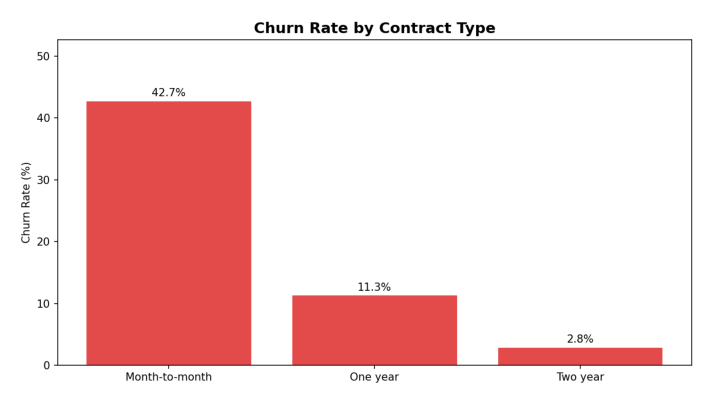

In [6]:
img = mpimg.imread('reports/figures/churn_by_contract.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [7]:
churn_by(df, 'tenure_band')

,total,churned,churn_rate
tenure_band,,,
0–12 mo,2186,1037,0.474382
13–24 mo,1024,294,0.287109
25–36 mo,832,180,0.216346
37–48 mo,762,145,0.190289
49–60 mo,832,120,0.144231
61–72 mo,1407,93,0.066098


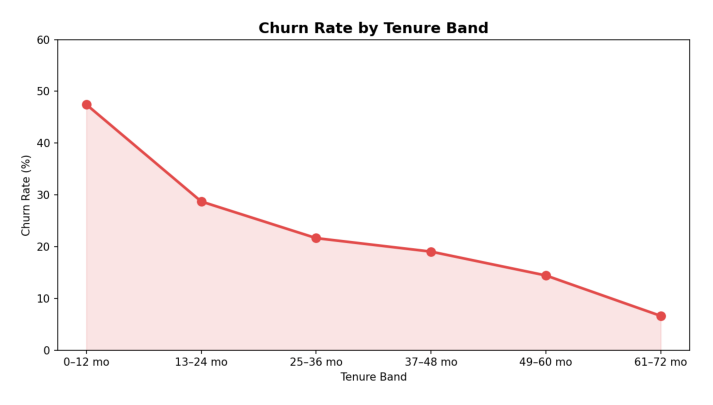

In [9]:
img = mpimg.imread('reports/figures/churn_by_tenure.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [10]:
churn_by(df, 'paymentmethod')

,total,churned,churn_rate
paymentmethod,,,
Electronic check,2365,1071,0.452854
Mailed check,1612,308,0.191067
Bank transfer (automatic),1544,258,0.167098
Credit card (automatic),1522,232,0.152431


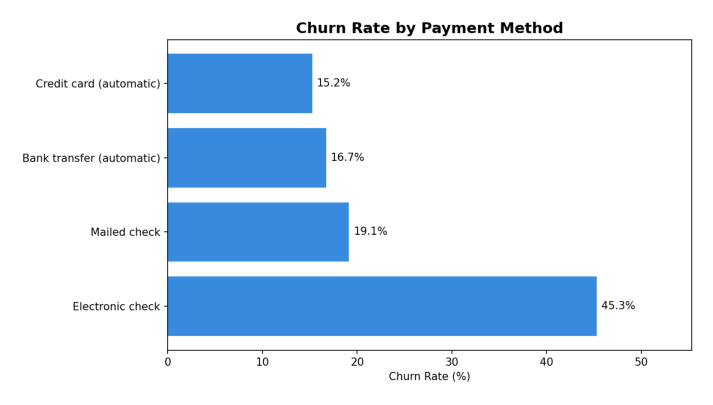

In [11]:
img = mpimg.imread('reports/figures/churn_by_payment.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [12]:
churn_by(df, 'internetservice')

,total,churned,churn_rate
internetservice,,,
Fiber optic,3096,1297,0.418928
DSL,2421,459,0.189591
No,1526,113,0.074050


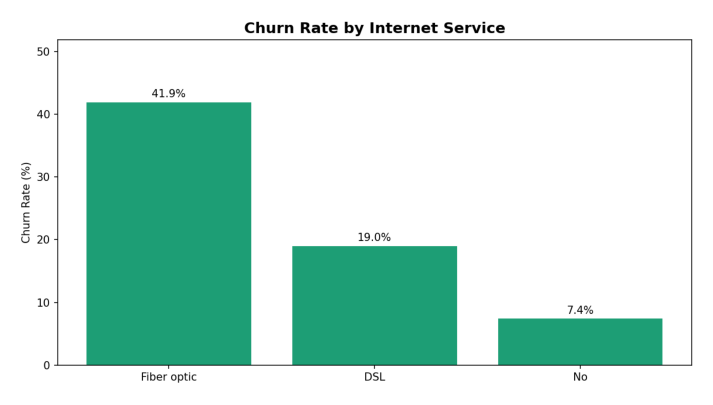

In [13]:
img = mpimg.imread('reports/figures/churn_by_internet.png')
plt.figure(figsize=(9, 5))
plt.imshow(img)
plt.axis('off')
plt.show()

In [14]:
churn_by(df, 'charge_band')

,total,churned,churn_rate
charge_band,,,
High,2604,936,0.359447
Premium,1295,418,0.322780
Medium,1409,326,0.231370
Low,1735,189,0.108934
